## §0 · Config & Imports

In [11]:
import requests, pandas as pd, numpy as np, time, pickle, warnings
from datetime import datetime, date
warnings.filterwarnings("ignore")

API_KEY  = "upIJ74md21T7tdxEJop2P8O3UP0ydqHQLzm0H1VB0hZSOmeyhJsxA5qO2F6Aft8U"   # ← paste your CBBD API key here
BASE_URL = "https://api.collegebasketballdata.com"
HEADERS  = {"Authorization": f"Bearer {API_KEY}"}

# Seasons to train on (season int = year season ENDS, e.g. 2024 = 2023-24)
SEASONS = list(range(2016, 2026))    # 10 seasons: 2015-16 through 2024-25
CURRENT_SEASON = 2026               # 2025-26 (for predictions)

print(f"Training seasons: {SEASONS[0]}–{SEASONS[-1]}")
print(f"Prediction season: {CURRENT_SEASON}")


Training seasons: 2016–2025
Prediction season: 2026


## §1 · Fetch Historical Games

In [12]:
def fetch_games(season, season_type="regular"):
    url = f"{BASE_URL}/games"
    params = {"season": season, "seasonType": season_type, "status": "final"}
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()
    return r.json()

all_games = []
for s in SEASONS:
    for stype in ["regular", "postseason"]:
        g = fetch_games(s, stype)
        all_games.extend(g)
        print(f"Season {s} {stype:12s}: {len(g):5d} games")
        time.sleep(0.25)

games_raw = pd.DataFrame(all_games)
print(f"\nTotal raw games : {len(games_raw)}")
print(f"Columns         : {games_raw.columns.tolist()}")


Season 2016 regular     :  3000 games
Season 2016 postseason  :   147 games
Season 2017 regular     :  3000 games
Season 2017 postseason  :   126 games
Season 2018 regular     :  3000 games
Season 2018 postseason  :   134 games
Season 2019 regular     :  3000 games
Season 2019 postseason  :   140 games
Season 2020 regular     :  3000 games
Season 2020 postseason  :     0 games
Season 2021 regular     :  3000 games
Season 2021 postseason  :    89 games
Season 2022 regular     :  3000 games
Season 2022 postseason  :   130 games
Season 2023 regular     :  3000 games
Season 2023 postseason  :   113 games
Season 2024 regular     :  3000 games
Season 2024 postseason  :   120 games
Season 2025 regular     :  3000 games
Season 2025 postseason  :   123 games

Total raw games : 31122
Columns         : ['id', 'sourceId', 'seasonLabel', 'season', 'seasonType', 'tournament', 'startDate', 'startTimeTbd', 'neutralSite', 'conferenceGame', 'gameType', 'status', 'gameNotes', 'attendance', 'homeTeamId', 

## §2 · Clean & Filter Games

In [13]:
games = games_raw[games_raw["status"] == "final"].copy()
games = games.dropna(subset=["homePoints", "awayPoints"]).copy()

# Parse date
games["startDate"] = pd.to_datetime(games["startDate"], utc=True)
games["game_date"] = games["startDate"].dt.date

# Target
games["home_win"] = games["homeWinner"].astype(int)

# Context flags
games["neutral"]        = games["neutralSite"].fillna(False).astype(int)
games["home_advantage"] = 1 - games["neutral"]
games["conf_game"]      = games["conferenceGame"].fillna(False).astype(int)

# Seeds (postseason / tournament games)
games["homeSeed"] = pd.to_numeric(games.get("homeSeed", np.nan), errors="coerce")
games["awaySeed"] = pd.to_numeric(games.get("awaySeed", np.nan), errors="coerce")
games["seed_diff"] = games["homeSeed"] - games["awaySeed"]

# ELO embedded in game data — pre-game values
games["elo_diff"] = (
    pd.to_numeric(games["homeTeamEloStart"], errors="coerce") -
    pd.to_numeric(games["awayTeamEloStart"], errors="coerce")
)

games_sorted = games.sort_values("startDate").reset_index(drop=True)

print(f"Final games    : {len(games_sorted)}")
print(f"Home win rate  : {games_sorted.home_win.mean():.3f}")
print(f"Neutral-site   : {games_sorted.neutral.sum()} ({games_sorted.neutral.mean():.2%})")
games_sorted[["homeTeam","awayTeam","homePoints","awayPoints",
              "home_win","neutral","elo_diff","season"]].head()


Final games    : 31122
Home win rate  : 0.720
Neutral-site   : 4142 (13.31%)


,homeTeam,awayTeam,homePoints,awayPoints,home_win,neutral,elo_diff,season
0,Columbia,Kean,107,62,1,0,88,2016
1,Eastern Michigan,Vermont,70,50,1,0,-12,2016
2,UL Monroe,McMurry,88,43,1,0,94,2016
3,Yale,Fairfield,70,57,1,1,228,2016
4,North Dakota,Minnesota Morris,99,69,1,0,-4,2016


## §3 · Rolling Win% Form (no data leakage)

In [14]:
# Build per-team record table
# Use rename() so column count never mismatches (avoids ValueError if extra cols exist)
home_rec = (
    games_sorted[["startDate","homeTeam","home_win","season"]]
    .rename(columns={"homeTeam": "team", "home_win": "win"})
    .copy()
)

away_rec = games_sorted[["startDate","awayTeam","home_win","season"]].copy()
away_rec["win"] = 1 - away_rec["home_win"]
# Select only the 4 columns we want BEFORE renaming (drops the 'home_win' column)
away_rec = (
    away_rec[["startDate","awayTeam","win","season"]]
    .rename(columns={"awayTeam": "team"})
)

all_rec = pd.concat([home_rec, away_rec]).sort_values("startDate").reset_index(drop=True)

# shift(1) prevents using the current game's result
all_rec["roll_win10"] = (
    all_rec.groupby("team")["win"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
)
all_rec["season_winpct"] = (
    all_rec.groupby(["team","season"])["win"]
    .transform(lambda x: x.shift(1).expanding(min_periods=5).mean())
)

# Build lookup dict: (startDate_timestamp, team) -> {roll_win10, season_winpct}
form_map = (
    all_rec.set_index(["startDate","team"])
    [["roll_win10","season_winpct"]]
    .to_dict("index")
)

print(f"Form map entries : {len(form_map)}")
print(all_rec[["team","win","roll_win10","season_winpct"]].dropna().tail(5).to_string())


Form map entries : 62244
           team  win  roll_win10  season_winpct
62239      Duke    0         1.0       0.894737
62240  Nebraska    1         0.8       0.777778
62241       UCF    0         0.8       0.750000
62242   Houston    0         1.0       0.842105
62243   Florida    1         0.9       0.950000


## §4 · Adjusted Efficiency Ratings (KenPom-style)

In [15]:
def fetch_adj_ratings(season):
    r = requests.get(f"{BASE_URL}/ratings/adjusted",
                     headers=HEADERS, params={"season": season}, timeout=30)
    r.raise_for_status()
    rows = r.json()
    for row in rows:
        row["season"] = season
    return rows

adj_list = []
for s in SEASONS:
    data = fetch_adj_ratings(s)
    adj_list.extend(data)
    print(f"Season {s}: {len(data)} teams")
    time.sleep(0.25)

adj_ratings = pd.DataFrame(adj_list)
print(f"\nTotal rows : {len(adj_ratings)}")
print(f"Columns    : {adj_ratings.columns.tolist()}")
adj_ratings[["season","team","offensiveRating","defensiveRating","netRating"]].head(5)


Season 2016: 348 teams
Season 2017: 347 teams
Season 2018: 348 teams
Season 2019: 350 teams
Season 2020: 351 teams
Season 2021: 345 teams
Season 2022: 356 teams
Season 2023: 361 teams
Season 2024: 362 teams
Season 2025: 364 teams

Total rows : 3532
Columns    : ['season', 'teamId', 'team', 'conference', 'offensiveRating', 'defensiveRating', 'netRating', 'rankings']


,season,team,offensiveRating,defensiveRating,netRating
0,2016,Villanova,120.3,90.1,30.2
1,2016,Michigan State,122.3,93.4,28.9
2,2016,Virginia,120.0,91.2,28.8
3,2016,Kansas,119.5,91.5,28.0
4,2016,North Carolina,122.6,94.7,27.9


## §5 · Team Season Stats (Four Factors + Pace)

In [16]:
def fetch_team_stats(season):
    r = requests.get(f"{BASE_URL}/stats/team/season",
                     headers=HEADERS, params={"season": season}, timeout=30)
    r.raise_for_status()
    return r.json()

def flatten_stats(row):
    ts  = row.get("teamStats", {}) or {}
    ff  = ts.get("fourFactors", {}) or {}
    fg3 = ts.get("threePointFieldGoals", {}) or {}
    ft  = ts.get("freeThrows", {}) or {}
    rb  = ts.get("rebounds", {}) or {}
    fg  = ts.get("fieldGoals", {}) or {}
    return {
        "team"    : row.get("team"),
        "season"  : row.get("season"),
        "games"   : row.get("games", np.nan),
        "wins"    : row.get("wins", np.nan),
        "pace"    : row.get("pace", np.nan),
        "fg_pct"  : fg.get("pct", np.nan),
        "fg3_pct" : fg3.get("pct", np.nan),
        "ft_pct"  : ft.get("pct", np.nan),
        # Dean Oliver's Four Factors
        "efg_pct" : ff.get("effectiveFieldGoalPct", np.nan),
        "to_ratio": ff.get("turnoverRatio", np.nan),
        "orb_pct" : ff.get("offensiveReboundPct", np.nan),
        "ft_rate" : ff.get("freeThrowRate", np.nan),
        # Additional
        "orb_raw" : rb.get("offensive", np.nan),
        "drb_raw" : rb.get("defensive", np.nan),
    }

stats_list = []
for s in SEASONS:
    raw = fetch_team_stats(s)
    for row in raw:
        row["season"] = s
    stats_list.extend(raw)
    print(f"Season {s}: {len(raw)} teams")
    time.sleep(0.25)

team_stats = pd.DataFrame([flatten_stats(r) for r in stats_list])
print(f"\nFlattened rows : {len(team_stats)}")
team_stats.head(3)


Season 2016: 648 teams
Season 2017: 644 teams
Season 2018: 659 teams
Season 2019: 653 teams
Season 2020: 664 teams
Season 2021: 493 teams
Season 2022: 680 teams
Season 2023: 706 teams
Season 2024: 717 teams
Season 2025: 700 teams

Flattened rows : 6564


,team,season,games,wins,pace,fg_pct,fg3_pct,ft_pct,efg_pct,to_ratio,orb_pct,ft_rate,orb_raw,drb_raw
0,Abilene Christian,2016,31,13,61.8,45.2,36.7,70.1,51.4,0.21,27.1,38.3,269,722
1,Air Force,2016,32,14,68.1,42.8,33.9,68.3,48.5,0.19,25.6,40.2,283,824
2,Akron,2016,35,26,63.8,43.2,38.3,68.4,52.8,0.17,28.5,31.2,373,937


## §6 · Feature Assembly

In [17]:
def lookup_adj(team, season, df=None):
    if df is None:
        df = adj_ratings
    m = df[(df["team"] == team) & (df["season"] == season)]
    if m.empty:
        m = df[(df["team"] == team) & (df["season"] == season - 1)]
    return m.iloc[0] if not m.empty else pd.Series(dtype=float)

def lookup_stats(team, season, df=None):
    if df is None:
        df = team_stats
    m = df[(df["team"] == team) & (df["season"] == season)]
    if m.empty:
        m = df[(df["team"] == team) & (df["season"] == season - 1)]
    return m.iloc[0] if not m.empty else pd.Series(dtype=float)

def get_form(team, ts):
    val = form_map.get((ts, team), {})
    return val.get("roll_win10", np.nan), val.get("season_winpct", np.nan)

feature_rows = []
for _, g in games_sorted.iterrows():
    ht = g["homeTeam"]
    at = g["awayTeam"]
    s  = g["season"]
    ts = g["startDate"]

    h_adj  = lookup_adj(ht, s)
    a_adj  = lookup_adj(at, s)
    h_stat = lookup_stats(ht, s)
    a_stat = lookup_stats(at, s)
    h_r10, h_swp = get_form(ht, ts)
    a_r10, a_swp = get_form(at, ts)

    feat = {
        # ELO (pre-game, from API)
        "elo_diff"         : g.get("elo_diff", np.nan),
        # Game context
        "home_advantage"   : g.get("home_advantage", 1),
        "conf_game"        : g.get("conf_game", 0),
        "seed_diff"        : g.get("seed_diff", np.nan),
        # Adjusted efficiency (KenPom-style)
        "adj_off_diff"     : h_adj.get("offensiveRating", np.nan) - a_adj.get("offensiveRating", np.nan),
        "adj_def_diff"     : a_adj.get("defensiveRating", np.nan) - h_adj.get("defensiveRating", np.nan),
        "net_rating_diff"  : h_adj.get("netRating", np.nan) - a_adj.get("netRating", np.nan),
        # Four Factors diffs (positive = home advantage)
        "efg_diff"         : h_stat.get("efg_pct", np.nan) - a_stat.get("efg_pct", np.nan),
        "to_diff"          : a_stat.get("to_ratio", np.nan) - h_stat.get("to_ratio", np.nan),
        "orb_diff"         : h_stat.get("orb_pct", np.nan) - a_stat.get("orb_pct", np.nan),
        "ftr_diff"         : h_stat.get("ft_rate", np.nan) - a_stat.get("ft_rate", np.nan),
        # Shooting
        "fg3_diff"         : h_stat.get("fg3_pct", np.nan) - a_stat.get("fg3_pct", np.nan),
        "ft_pct_diff"      : h_stat.get("ft_pct", np.nan) - a_stat.get("ft_pct", np.nan),
        # Pace
        "pace_diff"        : h_stat.get("pace", np.nan) - a_stat.get("pace", np.nan),
        # Form
        "form_roll10_diff" : (h_r10 - a_r10) if (pd.notna(h_r10) and pd.notna(a_r10)) else np.nan,
        "form_season_diff" : (h_swp - a_swp) if (pd.notna(h_swp) and pd.notna(a_swp)) else np.nan,
        # Target
        "home_win"         : g["home_win"],
    }
    feature_rows.append(feat)

feat_df = pd.DataFrame(feature_rows)
print(f"Feature rows  : {len(feat_df)}")
print(f"Home win rate : {feat_df.home_win.mean():.3f}")
print(f"NaN counts:\n{feat_df.isna().sum().sort_values(ascending=False).head(10)}")
feat_df.describe()


Feature rows  : 31122
Home win rate : 0.720
NaN counts:
seed_diff           30529
form_season_diff    12991
adj_def_diff         4777
net_rating_diff      4777
adj_off_diff         4777
form_roll10_diff     2516
to_diff               226
ft_pct_diff            29
efg_diff               29
orb_diff               29
dtype: int64


,elo_diff,home_advantage,conf_game,seed_diff,adj_off_diff,adj_def_diff,net_rating_diff,efg_diff,to_diff,orb_diff,ftr_diff,fg3_diff,ft_pct_diff,pace_diff,form_roll10_diff,form_season_diff,home_win
count,31122.000000,31122.000000,31122.00000,593.000000,26345.000000,26345.000000,26345.000000,31093.000000,30896.000000,31093.000000,31093.000000,31093.000000,31093.000000,31122.000000,28606.000000,18131.000000,31122.000000
mean,77.042767,0.866911,0.21933,-6.156830,1.475422,1.583762,3.059040,1.734886,0.018336,-0.117358,1.502441,1.011922,1.112646,0.546408,0.088773,0.051684,0.720262
std,242.612413,0.339676,0.41380,4.322008,28.163593,17.224388,19.274489,5.750133,0.067490,5.533717,7.750451,4.978190,7.331186,9.904940,0.293069,0.281718,0.448878
min,-1218.000000,0.000000,0.00000,-15.000000,-1077.500000,-539.900000,-666.100000,-26.200000,-0.480000,-36.900000,-58.600000,-32.800000,-36.400000,-71.400000,-1.000000,-1.000000,0.000000
25%,-76.000000,1.000000,0.00000,-9.000000,-2.300000,-1.900000,-2.500000,-1.900000,-0.010000,-3.600000,-3.500000,-2.000000,-3.100000,-4.100000,-0.100000,-0.141414,0.000000
50%,72.000000,1.000000,0.00000,-5.000000,0.800000,0.900000,1.500000,0.900000,0.010000,-0.100000,0.900000,0.600000,0.600000,-0.100000,0.100000,0.041667,1.000000
75%,220.750000,1.000000,0.00000,-3.000000,5.400000,5.000000,8.200000,4.300000,0.040000,3.400000,5.800000,3.300000,4.600000,3.900000,0.300000,0.233333,1.000000
max,1571.000000,1.000000,1.00000,0.000000,1093.400000,518.200000,577.600000,41.600000,2.510000,32.300000,54.800000,38.200000,79.700000,70.100000,1.000000,1.000000,1.000000


## §7 · Dataset Prep

In [18]:
from sklearn.model_selection import train_test_split

FEATURE_COLS = [c for c in feat_df.columns if c != "home_win"]
X = feat_df[FEATURE_COLS].copy()
y = feat_df["home_win"].copy()

# Drop rows where ALL key efficiency features are NaN
key_feats = ["elo_diff", "net_rating_diff", "adj_off_diff"]
mask = X[key_feats].isna().all(axis=1)
X = X[~mask].reset_index(drop=True)
y = y[~mask].reset_index(drop=True)
print(f"Dropped {mask.sum()} rows missing all key features")

medians = X.median()
X = X.fillna(medians)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {len(X_train):,}")
print(f"Test  : {len(X_test):,}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")


Dropped 0 rows missing all key features
Train : 24,897
Test  : 6,225
Features (16): ['elo_diff', 'home_advantage', 'conf_game', 'seed_diff', 'adj_off_diff', 'adj_def_diff', 'net_rating_diff', 'efg_diff', 'to_diff', 'orb_diff', 'ftr_diff', 'fg3_diff', 'ft_pct_diff', 'pace_diff', 'form_roll10_diff', 'form_season_diff']


## §8 · XGBoost Cross-Validation

In [19]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss

xgb_model = xgb.XGBClassifier(
    n_estimators     = 500,
    max_depth        = 4,
    learning_rate    = 0.025,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 8,
    gamma            = 0.2,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    use_label_encoder= False,
    eval_metric      = "logloss",
    random_state     = 42,
    n_jobs           = -1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc   = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="accuracy")
auc   = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="roc_auc")
brier = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="neg_brier_score")

print("=== 5-Fold Cross-Validation ===")
print(f"Accuracy : {acc.mean():.4f}  ±{acc.std():.4f}")
print(f"ROC-AUC  : {auc.mean():.4f}  ±{auc.std():.4f}")
print(f"Brier    : {(-brier).mean():.4f}  ±{brier.std():.4f}")


=== 5-Fold Cross-Validation ===
Accuracy : 0.7969  ±0.0035
ROC-AUC  : 0.8500  ±0.0047
Brier    : 0.1369  ±0.0019


## §9 · Calibrated Model (Isotonic Regression)

In [20]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

xgb_model.fit(X_train, y_train)

cal_model = CalibratedClassifierCV(xgb_model, method="isotonic", cv=5)
cal_model.fit(X_train, y_train)

y_proba = cal_model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

print("=== Test Set Performance ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Brier    : {brier_score_loss(y_test, y_proba):.4f}")


=== Test Set Performance ===
Accuracy : 0.8000
ROC-AUC  : 0.8531
Brier    : 0.1358


## §9a · Save Model Assets  ← run this before launching cbb_app.py

In [21]:
# Fetch current-season data for live predictions
print(f"Fetching {CURRENT_SEASON} adjusted ratings...")
curr_adj_raw = fetch_adj_ratings(CURRENT_SEASON)
curr_adj_df  = pd.DataFrame(curr_adj_raw)
print(f"  {len(curr_adj_df)} teams")

print(f"Fetching {CURRENT_SEASON} team stats...")
curr_stats_raw = fetch_team_stats(CURRENT_SEASON)
for r in curr_stats_raw:
    r["season"] = CURRENT_SEASON
curr_stats_df = pd.DataFrame([flatten_stats(r) for r in curr_stats_raw])
print(f"  {len(curr_stats_df)} teams")

# Combine historical + current season
all_adj   = pd.concat([adj_ratings, curr_adj_df], ignore_index=True)
all_stats = pd.concat([team_stats,  curr_stats_df], ignore_index=True)

# Latest rolling form per team (for live predictions)
latest_form_roll   = all_rec.groupby("team")["roll_win10"].last().dropna().to_dict()
latest_form_season = all_rec.groupby("team")["season_winpct"].last().dropna().to_dict()

assets = {
    "model"              : cal_model,
    "feature_cols"       : FEATURE_COLS,
    "medians"            : medians.to_dict(),
    "adj_ratings"        : all_adj,
    "team_stats"         : all_stats,
    "latest_form_roll"   : latest_form_roll,
    "latest_form_season" : latest_form_season,
    "latest_season"      : max(SEASONS),
    "current_season"     : CURRENT_SEASON,
}

with open("cbb_model_assets.pkl", "wb") as f:
    pickle.dump(assets, f)

print("\n✅ cbb_model_assets.pkl saved!")
print(f"  adj_ratings rows  : {len(all_adj)}")
print(f"  team_stats rows   : {len(all_stats)}")
print(f"  form teams (roll) : {len(latest_form_roll)}")


Fetching 2026 adjusted ratings...
  365 teams
Fetching 2026 team stats...
  726 teams

✅ cbb_model_assets.pkl saved!
  adj_ratings rows  : 3897
  team_stats rows   : 7290
  form teams (roll) : 776


## §10 · Feature Importance

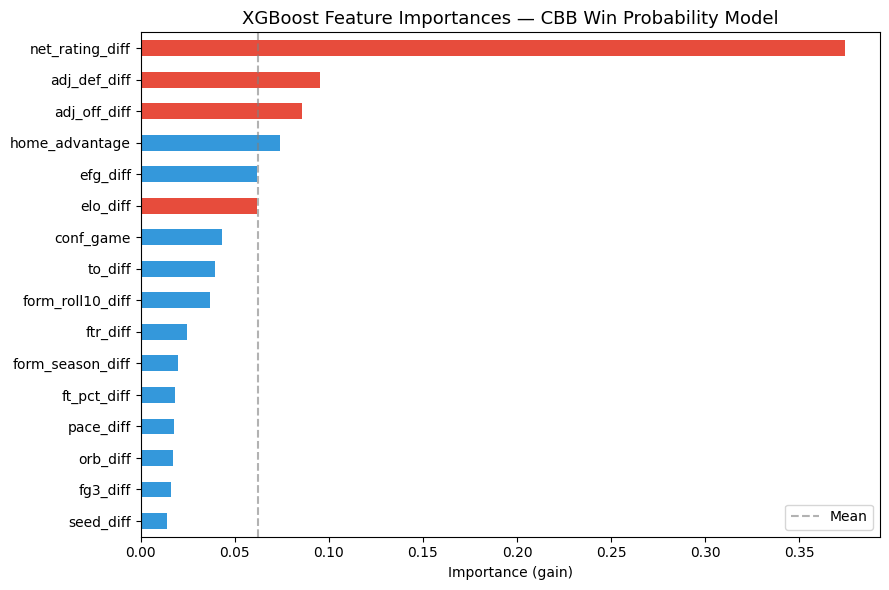


Top 5 features:
net_rating_diff    0.374216
adj_def_diff       0.095141
adj_off_diff       0.085644
home_advantage     0.073886
efg_diff           0.061863


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fi = (pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
      .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#e74c3c" if "elo" in i or "adj" in i or "net" in i else "#3498db" for i in fi.index]
fi.plot.barh(ax=ax, color=colors)
ax.set_title("XGBoost Feature Importances — CBB Win Probability Model", fontsize=13)
ax.set_xlabel("Importance (gain)")
ax.axvline(fi.mean(), color="gray", linestyle="--", alpha=0.6, label="Mean")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(fi.sort_values(ascending=False).head(5).to_string())


## §11 · Today's Predictions

In [23]:
def fetch_today():
    today = date.today().isoformat()
    r = requests.get(f"{BASE_URL}/games", headers=HEADERS, params={
        "startDateRange": f"{today}T00:00:00Z",
        "endDateRange"  : f"{today}T23:59:59Z",
    }, timeout=30)
    r.raise_for_status()
    return pd.DataFrame(r.json())

def predict_games(sched_df, adj_df, stats_df, form_roll, form_seas):
    rows = []
    for _, g in sched_df.iterrows():
        ht = g.get("homeTeam", "")
        at = g.get("awayTeam", "")
        s  = g.get("season", CURRENT_SEASON)

        h_adj  = lookup_adj(ht, s, adj_df)
        a_adj  = lookup_adj(at, s, adj_df)
        h_stat = lookup_stats(ht, s, stats_df)
        a_stat = lookup_stats(at, s, stats_df)
        h_r10  = form_roll.get(ht, 0.5)
        a_r10  = form_roll.get(at, 0.5)
        h_swp  = form_seas.get(ht, 0.5)
        a_swp  = form_seas.get(at, 0.5)

        h_elo = pd.to_numeric(g.get("homeTeamEloStart"), errors="coerce")
        a_elo = pd.to_numeric(g.get("awayTeamEloStart"), errors="coerce")
        neutral = 1 if g.get("neutralSite", False) else 0

        rows.append({
            "elo_diff"         : (h_elo - a_elo) if (pd.notna(h_elo) and pd.notna(a_elo)) else np.nan,
            "home_advantage"   : 1 - neutral,
            "conf_game"        : 1 if g.get("conferenceGame", False) else 0,
            "seed_diff"        : np.nan,
            "adj_off_diff"     : h_adj.get("offensiveRating", np.nan) - a_adj.get("offensiveRating", np.nan),
            "adj_def_diff"     : a_adj.get("defensiveRating", np.nan) - h_adj.get("defensiveRating", np.nan),
            "net_rating_diff"  : h_adj.get("netRating", np.nan) - a_adj.get("netRating", np.nan),
            "efg_diff"         : h_stat.get("efg_pct", np.nan) - a_stat.get("efg_pct", np.nan),
            "to_diff"          : a_stat.get("to_ratio", np.nan) - h_stat.get("to_ratio", np.nan),
            "orb_diff"         : h_stat.get("orb_pct", np.nan) - a_stat.get("orb_pct", np.nan),
            "ftr_diff"         : h_stat.get("ft_rate", np.nan) - a_stat.get("ft_rate", np.nan),
            "fg3_diff"         : h_stat.get("fg3_pct", np.nan) - a_stat.get("fg3_pct", np.nan),
            "ft_pct_diff"      : h_stat.get("ft_pct", np.nan) - a_stat.get("ft_pct", np.nan),
            "pace_diff"        : h_stat.get("pace", np.nan) - a_stat.get("pace", np.nan),
            "form_roll10_diff" : h_r10 - a_r10,
            "form_season_diff" : h_swp - a_swp,
        })

    feat = pd.DataFrame(rows, columns=FEATURE_COLS).fillna(pd.Series(medians))
    probs = cal_model.predict_proba(feat.values.astype("float32"))[:, 1]

    out = sched_df[["homeTeam","awayTeam","neutralSite"]].copy().reset_index(drop=True)
    out["home_prob"]  = probs
    out["away_prob"]  = 1 - probs
    out["winner"]     = np.where(probs >= 0.5, out["homeTeam"], out["awayTeam"])
    out["confidence"] = np.maximum(probs, 1 - probs)
    return out.sort_values("confidence", ascending=False)

sched = fetch_today()
print(f"Games today: {len(sched)}")

if not sched.empty and "homeTeam" in sched.columns:
    results = predict_games(sched, all_adj, all_stats,
                            latest_form_roll, latest_form_season)
    print()
    print(results[["awayTeam","homeTeam","away_prob","home_prob",
                    "winner","confidence"]].to_string(index=False))
else:
    print("No games today — try another date or check back during the season.")


Games today: 55

         awayTeam             homeTeam  away_prob  home_prob               winner  confidence
         Portland              Gonzaga   0.000738   0.999262              Gonzaga    0.999262
       Evansville              Belmont   0.001627   0.998373              Belmont    0.998373
        UL Monroe        South Alabama   0.007179   0.992821        South Alabama    0.992821
         Maryland             Nebraska   0.016980   0.983020             Nebraska    0.983020
Mississippi State              Alabama   0.038812   0.961188              Alabama    0.961188
           Bryant                 UMBC   0.062931   0.937069                 UMBC    0.937069
    South Florida                 Rice   0.934553   0.065447        South Florida    0.934553
             Navy      Loyola Maryland   0.898265   0.101735                 Navy    0.898265
        San Diego         Oregon State   0.105401   0.894599         Oregon State    0.894599
        Texas A&M             Arkansas   0.

## §12 · Calibration Curve

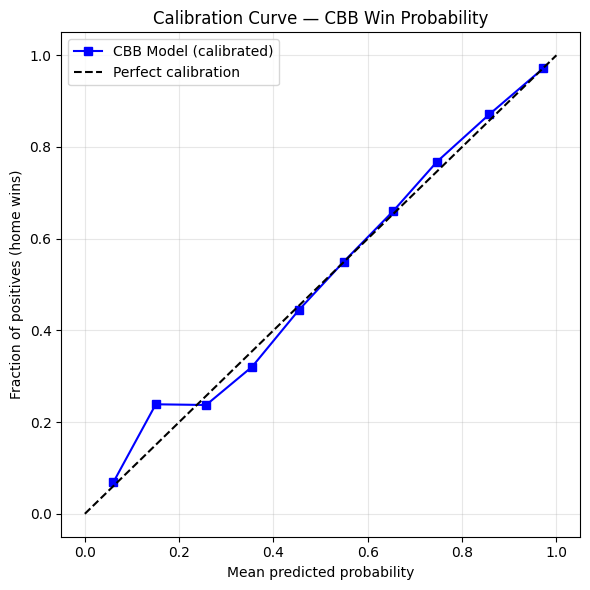

In [24]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred, frac_pos, "s-b", label="CBB Model (calibrated)")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (home wins)")
ax.set_title("Calibration Curve — CBB Win Probability")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## §13 · Notes

### Data Sources
| Source | Endpoint | Used For |
|--------|----------|----------|
| CBBD API `/games` | Game results + ELO | Target, ELO diff |
| CBBD API `/ratings/adjusted` | Adj. off/def efficiency | KenPom-style features |
| CBBD API `/stats/team/season` | Season stats | Four factors, pace, shooting |

### Key Features
| Feature | Description |
|---------|-------------|
| `elo_diff` | Pre-game ELO difference (home − away) — embedded in game data |
| `net_rating_diff` | Adjusted net efficiency home − away |
| `adj_off_diff` / `adj_def_diff` | Offensive / defensive efficiency diffs |
| `efg_diff` | Effective FG% diff (Dean Oliver Factor 1) |
| `to_diff` | Turnover ratio diff (Factor 2) |
| `orb_diff` | Offensive rebound % diff (Factor 3) |
| `ftr_diff` | Free throw rate diff (Factor 4) |
| `home_advantage` | 1 = home court, 0 = neutral site |
| `form_roll10_diff` | Last 10-game win% diff |

### Season Convention
The API uses `season = year the season ENDS`
e.g., `season=2024` → 2023–24 season
